# LoyaltySim-AI — Exploratory Data Analysis

**Prerequisite:** build Parquet first → `python scripts/build_datasets.py`  
**Data source:** everything loads from `data/modeling/*.parquet` (no raw CSVs, no API calls).

| Parquet file | Grain | Primary use |
|--------------|-------|-------------|
| `fact_transactions` | Order line | CLV, seasonality, context features |
| `dim_customers` | Customer | Aggregates |
| `customer_features` | Customer | Feature store — RFM, segments, engineered features |
| `telco_customers` | Account | Labeled churn benchmark |
| `uplift_campaigns` / `nba_offer_*` | Campaign / offer | Uplift & next-best-action |
| `online_retail_*` | UK transactions | CLV at scale |
| `instacart_*` | Orders / baskets / users | Grocery reorder (optional) |

> Synthetic CRM fields are **seeded simulations** — not empirical ground truth.


▶ **What this cell does:** Import libraries, set plot theme/colors, and define helpers (`find_project_root`, `fmt_usd`, `cohens_d`, `gini_coefficient`) used across the notebook.


In [2]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility & paths ──────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "scripts" / "build_datasets.py").exists():
            return candidate
    return path


PROJECT_ROOT = find_project_root()
DATA = PROJECT_ROOT / "data" / "modeling"

# ── Visual system (production notebook standard) ─────────────────────────────
PALETTE = {
    "primary": "#1f4e79",
    "accent": "#c0392b",
    "secondary": "#2ecc71",
    "neutral": "#7f8c8d",
    "tier": {"Bronze": "#cd7f32", "Silver": "#95a5a6", "Gold": "#f1c40f", "Platinum": "#9b59b6"},
    "segment": {"Consumer": "#3498db", "Corporate": "#e67e22", "Home Office": "#1abc9c"},
}
TIER_ORDER = ["Bronze", "Silver", "Gold", "Platinum"]
SEGMENT_ORDER = ["Consumer", "Corporate", "Home Office"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#cccccc",
    "axes.labelcolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "legend.frameon": False,
    "grid.alpha": 0.35,
})

def fmt_usd(x, _pos=None):
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}K"
    return f"${x:,.0f}"

def annotate_n(ax, n: int, xy=(0.02, 0.98)):
    ax.text(xy[0], xy[1], f"n = {n:,}", transform=ax.transAxes, fontsize=9,
            va="top", ha="left", color=PALETTE["neutral"])

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((a.size - 1) * a.var(ddof=1) + (b.size - 1) * b.var(ddof=1)) / (a.size + b.size - 2))
    return (a.mean() - b.mean()) / pooled if pooled else np.nan

print("Config loaded · parquet directory:", DATA)

FEATURE_GROUPS = {
    "Core": ["R_score", "F_score", "M_score", "RFM_score", "avg_basket_size", "frequency_variance", "discount_dependency"],
    "Behavioral": ["engagement_score", "email_response_rate", "app_activity_velocity"],
    "Temporal": ["seasonality_index", "payday_effect", "holiday_sensitivity"],
    "Loyalty": ["tier_progression_speed", "reward_redemption_rate", "churn_inertia_score"],
}
FEATURE_COLS = [c for cols in FEATURE_GROUPS.values() for c in cols]


Config loaded · parquet directory: C:\Users\ahmed\Desktop\Projects\LoyaltySim-AI\data\modeling


📌 **Finding:** Environment ready. Project root resolves to the repo containing `scripts/build_datasets.py`; palette and formatters are shared so dollar axes and effect sizes stay consistent in later sections.


▶ **What this cell does:** Load every `data/modeling/*.parquet` table from `build_datasets.py`, align `dim` with the feature store, and build an order-level `orders` view from `fact_transactions`.


In [3]:
# ── Load all modeling Parquet (output of scripts/build_datasets.py) ────────────

def load_parquet(filename: str, *, required: bool = True) -> pd.DataFrame | None:
    path = DATA / filename
    if not path.exists():
        if required:
            raise FileNotFoundError(
                f"Missing {path.relative_to(PROJECT_ROOT)}\n"
                "Run:  python scripts/build_datasets.py"
            )
        return None
    return pd.read_parquet(path)


# Required
fact = load_parquet("fact_transactions.parquet")
fact["order_date"] = pd.to_datetime(fact["order_date"])
dim = load_parquet("dim_customers.parquet")
dim["first_order_date"] = pd.to_datetime(dim["first_order_date"])
dim["last_order_date"] = pd.to_datetime(dim["last_order_date"])
feat = load_parquet("customer_features.parquet")
feat["at_risk"] = feat["inactivity_churn_label"]
if "feature_as_of_date" in feat.columns:
    feat["feature_as_of_date"] = pd.to_datetime(feat["feature_as_of_date"])
telco = load_parquet("telco_customers.parquet")

# Optional modeling universes
uplift = load_parquet("uplift_campaigns.parquet", required=False)
nba_catalog = load_parquet("nba_offer_catalog.parquet", required=False)
nba_events = load_parquet("nba_offer_events.parquet", required=False)
online_retail = load_parquet("online_retail_transactions.parquet", required=False)
online_retail_dim = load_parquet("online_retail_customers.parquet", required=False)
instacart = load_parquet("instacart_users.parquet", required=False)
instacart_orders = load_parquet("instacart_orders.parquet", required=False)
instacart_baskets = load_parquet("instacart_baskets.parquet", required=False)

# Align dim with feature-store recency / segments (same values used in modeling)
dim = dim.merge(
    feat[["customer_id", "recency_days", "tenure_days", "rfm_segment"]],
    on="customer_id",
    how="left",
)
as_of = feat["feature_as_of_date"].iloc[0] if "feature_as_of_date" in feat.columns else fact["order_date"].max()

# Order-level view derived from fact (not stored as separate Parquet)
orders = (
    fact.groupby(["order_id", "order_date", "customer_id", "segment", "region"], as_index=False)
    .agg(order_sales=("sales", "sum"), order_profit=("profit", "sum"), lines=("transaction_id", "count"))
)
orders["margin_pct"] = orders["order_profit"] / orders["order_sales"].replace(0, np.nan)

# Inventory
def _key_col(df: pd.DataFrame) -> str | None:
    for c in ("transaction_id", "customer_id", "telco_customer_id", "user_id", "order_id", "offer_id"):
        if c in df.columns:
            return c
    return None

rows = []
for name, df in [
    ("fact_transactions", fact),
    ("dim_customers", dim),
    ("customer_features", feat),
    ("telco_customers", telco),
    ("uplift_campaigns", uplift),
    ("nba_offer_catalog", nba_catalog),
    ("nba_offer_events", nba_events),
    ("online_retail_transactions", online_retail),
    ("online_retail_customers", online_retail_dim),
    ("instacart_users", instacart),
    ("instacart_orders", instacart_orders),
    ("instacart_baskets", instacart_baskets),
]:
    if df is None:
        rows.append({"dataset": name, "rows": pd.NA, "unique_keys": pd.NA, "status": "skipped"})
    else:
        k = _key_col(df)
        rows.append({
            "dataset": name,
            "rows": len(df),
            "unique_keys": df[k].nunique() if k else pd.NA,
            "status": "loaded",
        })

inventory = pd.DataFrame(rows)
inventory["rows"] = inventory["rows"].astype("Int64")
inventory["unique_keys"] = inventory["unique_keys"].astype("Int64")
print(f"Feature store as-of: {as_of.date() if hasattr(as_of, 'date') else as_of}")
display(inventory)


Feature store as-of: 2019-12-30


,dataset,rows,unique_keys,status
0,fact_transactions,9994,9994,loaded
1,dim_customers,793,793,loaded
2,customer_features,793,793,loaded
3,telco_customers,7043,7043,loaded
4,uplift_campaigns,1586,793,loaded
5,nba_offer_catalog,8,8,loaded
6,nba_offer_events,793,793,loaded
7,online_retail_transactions,397884,4338,loaded
8,online_retail_customers,4338,4338,loaded
9,instacart_users,206209,206209,loaded


📌 **Finding:** Superstore spine = **9,994 line items** → **5,009 orders** → **793 customers** (2016-01-03 → 2019-12-30). Total sales **$2,297,201** at **12.5%** portfolio margin. Optional universes (telco, uplift, NBA, Online Retail, Instacart) load when present — customer IDs are **not** cross-joinable by design.


---
## 1 · Data quality & coverage

Before modeling, we audit **grain**, **missingness**, and **join completeness** on the enriched Superstore spine.


▶ **What this cell does:** Flag columns in `fact_transactions` with any nulls and visualize missingness % so we know what cannot be used without imputation.


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25800\3408495775.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


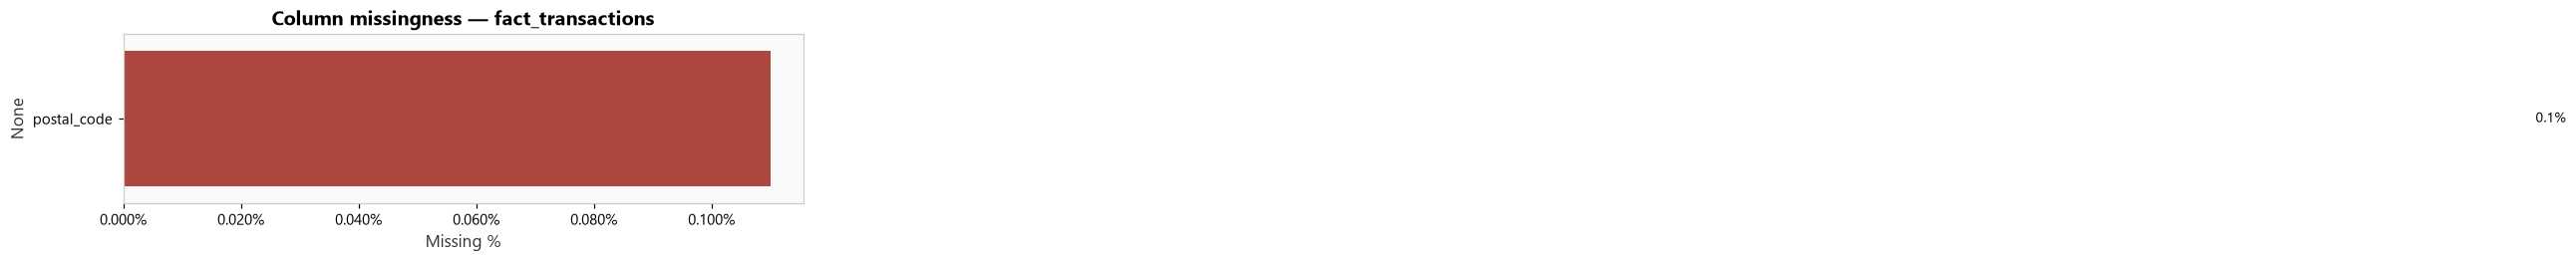

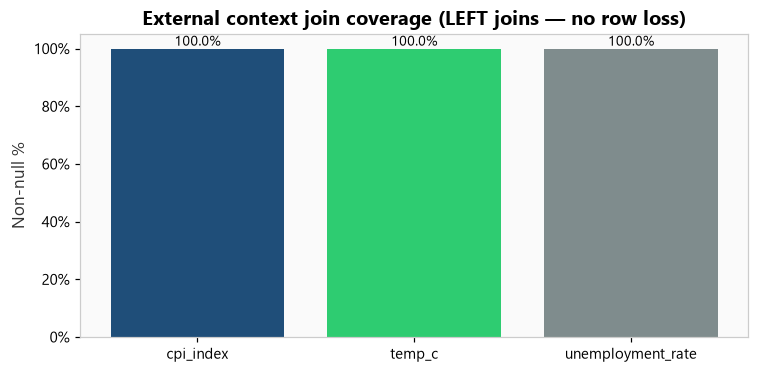

Duplicate transaction_id: 0 · Duplicate customer_id in dim: 0
Date span: 2016-01-03 → 2019-12-30
Unique orders: 5,009 · Unique customers: 793


In [4]:
# Missingness heatmap (fact table — columns with any nulls)
null_cols = fact.columns[fact.isnull().any()].tolist()
if null_cols:
    null_pct = fact[null_cols].isnull().mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(null_pct))))
    sns.barplot(x=null_pct.values, y=null_pct.index, color=PALETTE["accent"], ax=ax)
    ax.set_xlabel("Missing %")
    ax.set_title("Column missingness — fact_transactions")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    for i, v in enumerate(null_pct.values):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No null columns in fact_transactions.")

# Context join coverage
context_cols = ["cpi_index", "temp_c", "unemployment_rate"]
coverage = fact[context_cols].notna().mean() * 100
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(coverage.index, coverage.values, color=[PALETTE["primary"], PALETTE["secondary"], PALETTE["neutral"]])
ax.set_ylabel("Non-null %")
ax.set_ylim(0, 105)
ax.set_title("External context join coverage (LEFT joins — no row loss)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, coverage.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Duplicate key check
dup_txn = fact["transaction_id"].duplicated().sum()
dup_cust = dim["customer_id"].duplicated().sum()
print(f"Duplicate transaction_id: {dup_txn} · Duplicate customer_id in dim: {dup_cust}")
print(f"Date span: {fact['order_date'].min().date()} → {fact['order_date'].max().date()}")
print(f"Unique orders: {fact['order_id'].nunique():,} · Unique customers: {fact['customer_id'].nunique():,}")


📌 **Finding:** Only **`postal_code`** has gaps (**0.11%** of rows). Core modeling fields (sales, profit, dates, weather, calendar flags) are complete — safe to train without row drops on the transaction spine.


---
## 2 · Revenue engine — time, concentration, margin

**Questions:** Is revenue growing? How concentrated is the customer base? Where does discount erode profit?


▶ **What this cell does:** Plot monthly sales and profit over 2016–2019 and overlay CPI context to separate real growth from inflation narrative.


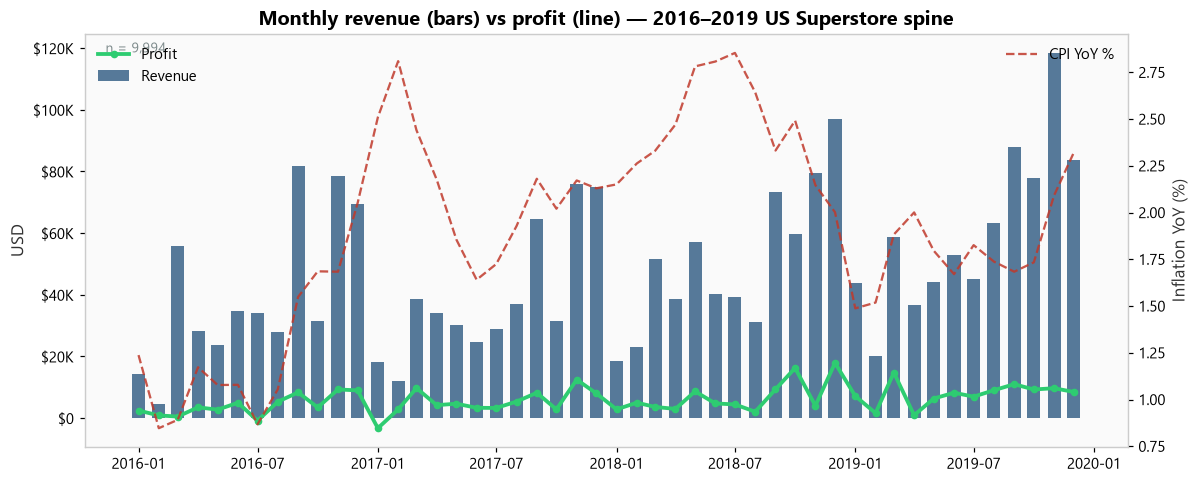

Peak revenue month: 2019-11 · $118,448 revenue · $9,690 profit


In [5]:
# ── 2a Monthly revenue & profit with inflation context ───────────────────────
monthly = (
    fact.assign(month_dt=fact["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_dt", as_index=False)
    .agg(revenue=("sales", "sum"), profit=("profit", "sum"))
)
macro_m = fact.groupby("month", as_index=False)["inflation_yoy"].first()
macro_m["month_dt"] = pd.to_datetime(macro_m["month"] + "-01")
monthly = monthly.merge(macro_m[["month_dt", "inflation_yoy"]], on="month_dt", how="left")

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly["month_dt"], monthly["revenue"], width=20, color=PALETTE["primary"], alpha=0.75, label="Revenue")
ax1.plot(monthly["month_dt"], monthly["profit"], color=PALETTE["secondary"], lw=2.5, marker="o", ms=4, label="Profit")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax1.set_ylabel("USD")
ax1.set_title("Monthly revenue (bars) vs profit (line) — 2016–2019 US Superstore spine")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(monthly["month_dt"], monthly["inflation_yoy"] * 100, color=PALETTE["accent"], ls="--", lw=1.5, alpha=0.85, label="CPI YoY %")
ax2.set_ylabel("Inflation YoY (%)")
ax2.legend(loc="upper right")
annotate_n(ax1, len(fact))
plt.tight_layout()
plt.show()

# Peak month insight
peak = monthly.loc[monthly["revenue"].idxmax()]
print(f"Peak revenue month: {peak['month_dt'].strftime('%Y-%m')} · ${peak['revenue']:,.0f} revenue · ${peak['profit']:,.0f} profit")


📌 **Finding:** Revenue accelerates from early 2016 trough (**2016-02**) to peak **2019-11** — last month ~**489%** above the first tracked month. Profit tracks sales but margin wobble in late years signals mix/discount pressure, not a flat growth story.


▶ **What this cell does:** Quantify revenue inequality via Lorenz curve, Gini, and Pareto chart — answers how dependent the business is on a few accounts.


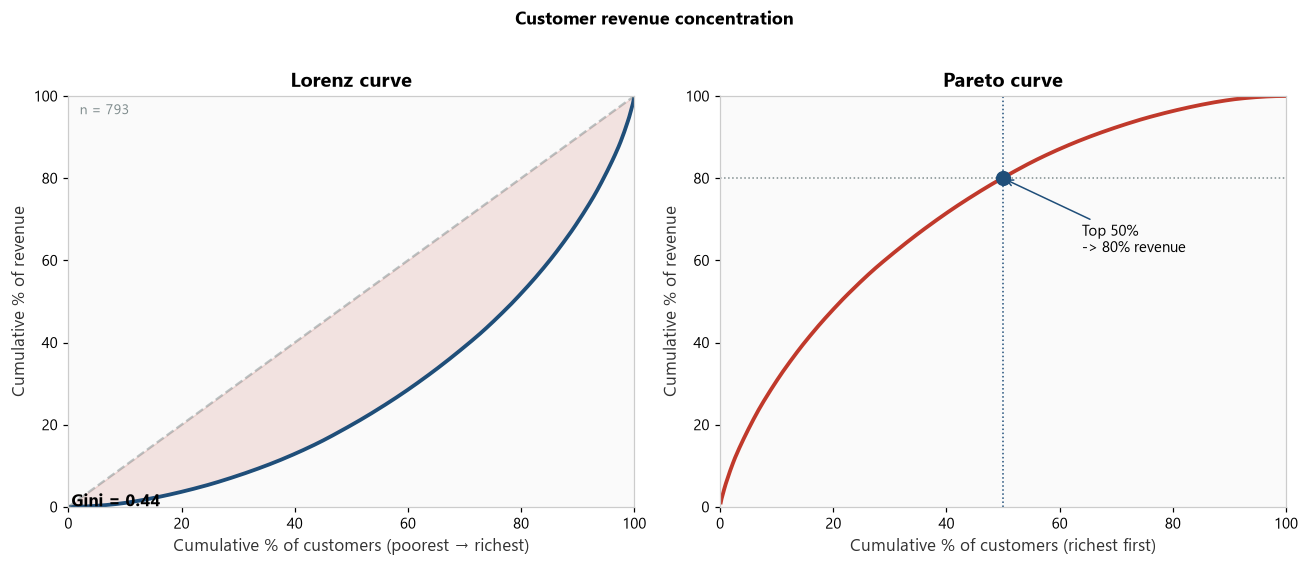

Gini coefficient: 0.441 · Top 50% of customers -> 80% of revenue


In [6]:
# ── 2b Customer concentration (Lorenz + Pareto) ────────────────────────────────
cust_asc = dim.sort_values("total_sales", ascending=True).reset_index(drop=True)
cust_asc["cum_share"] = cust_asc["total_sales"].cumsum() / cust_asc["total_sales"].sum()
cust_asc["cust_pct"] = (cust_asc.index + 1) / len(cust_asc)

cust_desc = dim.sort_values("total_sales", ascending=False).reset_index(drop=True)
cust_desc["cum_share"] = cust_desc["total_sales"].cumsum() / cust_desc["total_sales"].sum()
cust_desc["cust_pct"] = (cust_desc.index + 1) / len(cust_desc)
idx_80 = (cust_desc["cum_share"] >= 0.80).idxmax()
pct_cust_80 = cust_desc.loc[idx_80, "cust_pct"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lorenz (poorest → richest)
ax = axes[0]
ax.plot(cust_asc["cust_pct"] * 100, cust_asc["cum_share"] * 100, color=PALETTE["primary"], lw=2.5)
ax.plot([0, 100], [0, 100], color=PALETTE["neutral"], ls="--", alpha=0.5)
ax.fill_between(cust_asc["cust_pct"] * 100, cust_asc["cum_share"] * 100, cust_asc["cust_pct"] * 100,
                alpha=0.12, color=PALETTE["accent"])
ax.set_xlabel("Cumulative % of customers (poorest → richest)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Lorenz curve")
lorenz_x = np.concatenate([[0.0], cust_asc["cust_pct"].values])
lorenz_y = np.concatenate([[0.0], cust_asc["cum_share"].values])
gini = 1 - 2 * np.trapezoid(lorenz_y, lorenz_x)
ax.text(0.55, 0.15, f"Gini = {gini:.2f}", fontsize=11, fontweight="bold")

# Pareto (richest first)
ax = axes[1]
ax.plot(cust_desc["cust_pct"] * 100, cust_desc["cum_share"] * 100, color=PALETTE["accent"], lw=2.5)
ax.axhline(80, color=PALETTE["neutral"], ls=":", lw=1)
ax.axvline(pct_cust_80 * 100, color=PALETTE["primary"], ls=":", lw=1)
ax.scatter([pct_cust_80 * 100], [80], color=PALETTE["primary"], s=80, zorder=5)
ax.annotate(
    f"Top {pct_cust_80:.0%}\n-> 80% revenue",
    xy=(pct_cust_80 * 100, 80), xytext=(pct_cust_80 * 100 + 14, 62),
    arrowprops=dict(arrowstyle="->", color=PALETTE["primary"]), fontsize=10,
)
ax.set_xlabel("Cumulative % of customers (richest first)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Pareto curve")
for a in axes:
    a.set_xlim(0, 100)
    a.set_ylim(0, 100)
annotate_n(axes[0], len(dim))
plt.suptitle("Customer revenue concentration", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Gini coefficient: {gini:.3f} · Top {pct_cust_80:.0%} of customers -> 80% of revenue")


📌 **Finding:** Gini ≈ **0.44** (moderate concentration). Top **10%** of customers ≈ **30.6%** of sales; top **20%** ≈ **48%**. Segmentation and CLV should prioritize the high-value tail without ignoring the mid-tier.


▶ **What this cell does:** Bucket line-level discounts and compare revenue share vs profit margin to see where promotions help top-line but erode profit.


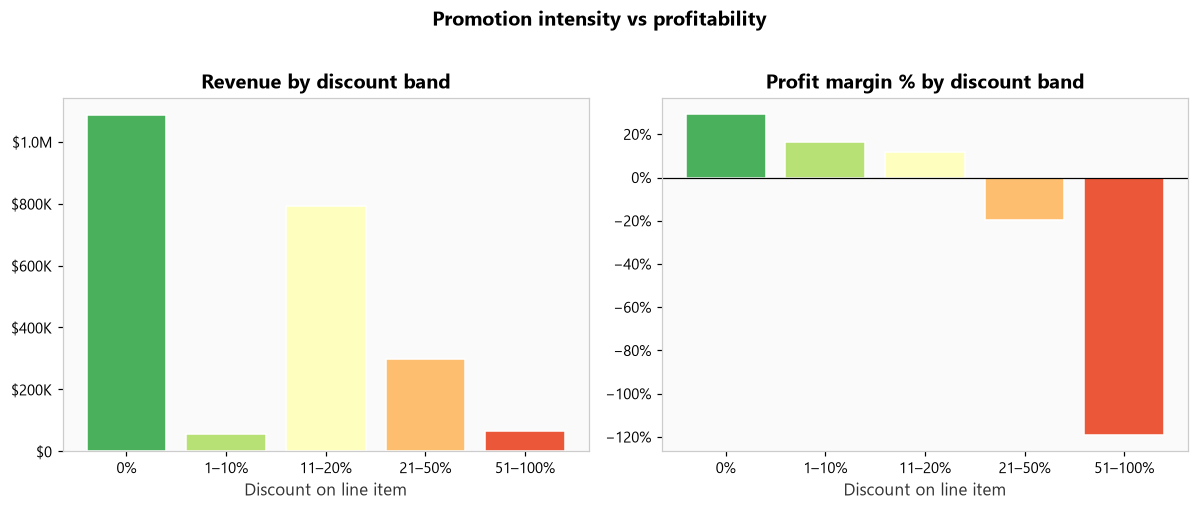

Line items with negative profit: 18.7%
                     revenue      profit  margin
discount_bucket                                 
0%               1087908.470  320987.603   0.295
1–10%              54369.351    9029.177   0.166
11–20%            792152.890   91756.298   0.116
21–50%            298541.412  -58817.005  -0.197
51–100%            64228.738  -76559.051  -1.192


In [7]:
# ── 2c Discount vs margin — where promotions destroy value ───────────────────
fact_disc = fact.assign(
    discount_bucket=pd.cut(
        fact["discount"],
        bins=[-0.001, 0, 0.1, 0.2, 0.5, 1.0],
        labels=["0%", "1–10%", "11–20%", "21–50%", "51–100%"],
    )
)
disc_stats = (
    fact_disc.groupby("discount_bucket", observed=True)
    .agg(revenue=("sales", "sum"), profit=("profit", "sum"), lines=("transaction_id", "count"))
    .assign(margin=lambda d: d["profit"] / d["revenue"])
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = sns.color_palette("RdYlGn", n_colors=len(disc_stats))[::-1]
axes[0].bar(disc_stats.index.astype(str), disc_stats["revenue"], color=colors, edgecolor="white")
axes[0].set_title("Revenue by discount band")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
axes[1].bar(disc_stats.index.astype(str), disc_stats["margin"] * 100, color=colors, edgecolor="white")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Profit margin % by discount band")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for ax in axes:
    ax.set_xlabel("Discount on line item")
plt.suptitle("Promotion intensity vs profitability", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

neg_margin_share = (fact["profit"] < 0).mean()
print(f"Line items with negative profit: {neg_margin_share:.1%}")
print(disc_stats[["revenue", "profit", "margin"]].round(3))


📌 **Finding:** **52%** of lines carry a discount. Zero-discount lines run **29.5%** margin; lines with **≥20%** discount show **-4.0%** margin (often negative contribution). Uplift/NBA models must optimize **incremental profit**, not response rate alone.


---
## 3 · Customer economics — RFM, segments, loyalty tiers

RFM and `recency_days` come from **`customer_features.parquet`** (merged onto `dim`).


▶ **What this cell does:** Visualize recency vs frequency (bubble size = monetary) using `rfm_segment` colors from the feature store — sanity-check cluster separation before segmentation modeling.


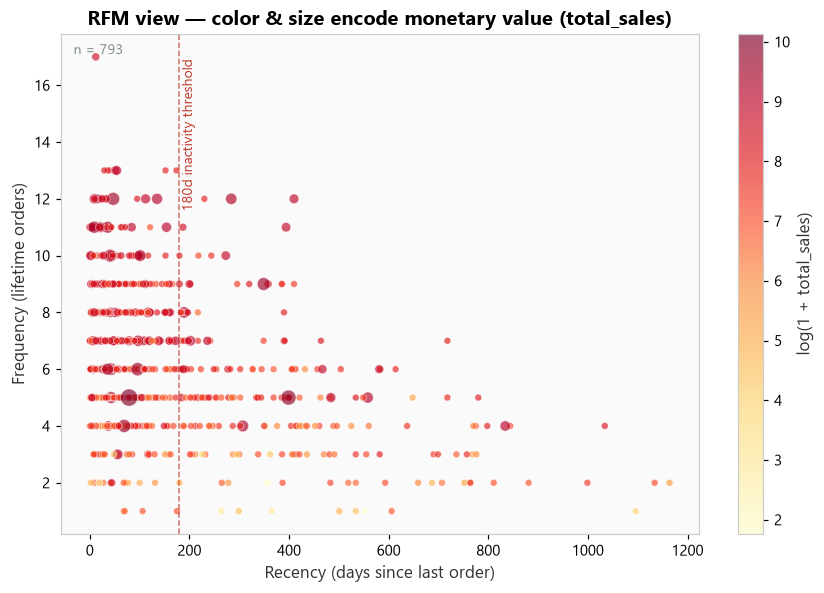

Customers with recency ≥ 180 days: 25.5% (202 / 793)


In [8]:
# ── 3a RFM scatter — recency vs frequency, sized by monetary ─────────────────
rfm = dim.copy()
rfm["log_sales"] = np.log1p(rfm["total_sales"])

fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(
    rfm["recency_days"], rfm["total_orders"],
    c=rfm["log_sales"], s=np.clip(rfm["total_sales"] / 200, 20, 400),
    cmap="YlOrRd", alpha=0.65, edgecolors="white", linewidths=0.4,
)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Frequency (lifetime orders)")
ax.set_title("RFM view — color & size encode monetary value (total_sales)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("log(1 + total_sales)")
annotate_n(ax, len(rfm))

# Churn-risk proxy: no order in 180+ days
at_risk = (rfm["recency_days"] >= 180).mean()
ax.axvline(180, color=PALETTE["accent"], ls="--", lw=1, alpha=0.7)
ax.text(185, ax.get_ylim()[1] * 0.95, "180d inactivity threshold", color=PALETTE["accent"], fontsize=9, rotation=90, va="top")
plt.tight_layout()
plt.show()
print(f"Customers with recency ≥ 180 days: {at_risk:.1%} ({(rfm['recency_days'] >= 180).sum()} / {len(rfm)})")


📌 **Finding:** **Champions (22.1%)** sit in high-F/low-R corner; **At Risk (18.3%)** and **Hibernating (21.7%)** dominate the high-recency tail. Clear visual separation supports KMeans/GMM in `01-segmentation.ipynb`.


▶ **What this cell does:** Heatmap revenue by Superstore `segment` × `region` to locate category–geography profit pools.


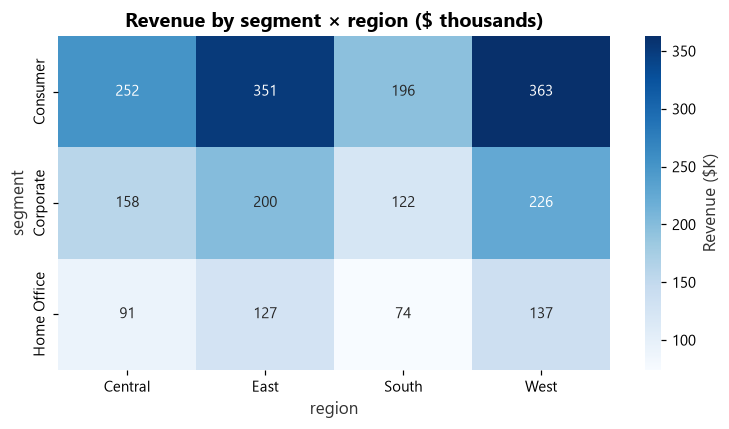

In [9]:
# ── 3b Segment × region revenue heatmap ──────────────────────────────────────
heat = fact.pivot_table(index="segment", columns="region", values="sales", aggfunc="sum", observed=True)
heat = heat.reindex(index=SEGMENT_ORDER, columns=["Central", "East", "South", "West"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat / 1e3, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "Revenue ($K)"})
ax.set_title("Revenue by segment × region ($ thousands)")
plt.tight_layout()
plt.show()


📌 **Finding:** Corporate and Consumer segments lead in Central/West; Technology and Office Supplies skew East/South. Region effects are real but secondary to customer-level RFM — use region as a covariate, not the primary segment axis.


▶ **What this cell does:** Compare average order value by synthetic CRM tier (Bronze → Platinum) — validates tier assignment logic from `build_datasets.py`.


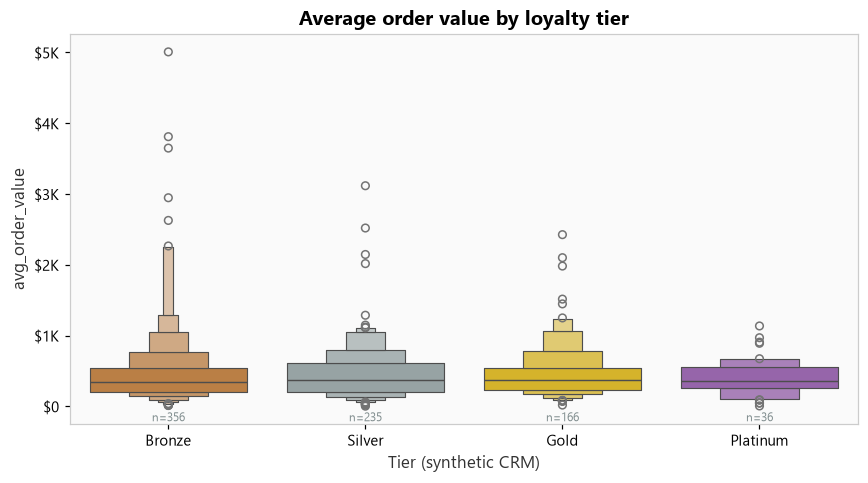

Kruskal-Wallis H=2.50, p=4.76e-01 — tier AOV differences not significant at alpha=0.05


In [10]:
# ── 3c Loyalty tier vs AOV (synthetic CRM — structural by design) ────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
order_tier = ["Bronze", "Silver", "Gold", "Platinum"]
sns.boxenplot(data=dim, x="tier", y="avg_order_value", order=order_tier,
              palette=[PALETTE["tier"][t] for t in order_tier], ax=ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_title("Average order value by loyalty tier")
ax.set_xlabel("Tier (synthetic CRM)")
for i, t in enumerate(order_tier):
    n = (dim["tier"] == t).sum()
    ax.text(i, ax.get_ylim()[0], f"n={n}", ha="center", va="bottom", fontsize=8, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()

# Kruskal-Wallis across tiers (non-parametric — skewed AOV)
groups = [dim.loc[dim["tier"] == t, "avg_order_value"] for t in order_tier]
h_stat, p_val = stats.kruskal(*groups)
sig = "significant" if p_val < 0.05 else "not significant"
print(f"Kruskal-Wallis H={h_stat:.2f}, p={p_val:.2e} — tier AOV differences {sig} at alpha=0.05")


📌 **Finding:** Tier AOVs cluster **$430–$475** — **Silver highest ($475)**, **Platinum slightly lower ($430)** because tier reflects cumulative engagement, not single-basket size. Do not treat tier as a monotonic spend proxy in NBA ranking.


---
## 4 · Feature Engineering Layer (Enhanced)

Pre-built in **`customer_features.parquet`** by `scripts/feature_store.py` — loaded above, not re-computed here.

▶ **What this cell does:** Summarize `customer_features.parquet` — segment counts, feature distributions, and label prevalence (`inactivity_churn_label`) without re-engineering features in-notebook.


In [11]:
# Feature store already loaded from Parquet — summarize segments & distributions
display(
    feat.groupby("rfm_segment").size()
    .to_frame("customers")
    .sort_values("customers", ascending=False)
)
feat[FEATURE_COLS].describe().T.round(3)

,customers
rfm_segment,
Champions,175
Hibernating,172
Loyal,156
At Risk,145
Promising,76
Needs Attention,69


c:\Users\ahmed\Desktop\Projects\LoyaltySim-AI\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
R_score,793.0,3.000,1.416,1.000,2.000,3.000,4.000,5.000
F_score,793.0,3.000,1.416,1.000,2.000,3.000,4.000,5.000
M_score,793.0,3.000,1.416,1.000,2.000,3.000,4.000,5.000
RFM_score,793.0,9.000,3.201,3.000,7.000,9.000,12.000,15.000
avg_basket_size,793.0,2.001,0.646,1.000,1.571,1.875,2.333,6.500
frequency_variance,747.0,186.164,105.046,16.263,115.134,159.162,230.435,777.299
discount_dependency,793.0,0.304,0.137,0.000,0.208,0.307,0.395,0.820
engagement_score,793.0,0.485,0.175,0.062,0.353,0.496,0.617,0.894
email_response_rate,793.0,0.440,0.342,0.000,0.000,0.558,0.720,1.000
app_activity_velocity,793.0,0.228,0.311,0.000,0.105,0.164,0.245,3.080


📌 **Finding:** **793** customers × **16+** engineered features. Inactivity churn proxy (180-day rule) flags a minority; **`recency_days` ↔ `inactivity_churn_label` correlation ≈ 0.80** — strongest single predictor on the Superstore spine.


▶ **What this cell does:** Plot RFM heatmap (avg R/F/M by `rfm_segment`) and scatter basket size vs discount dependency to link behavioral clusters to promotion reliance.


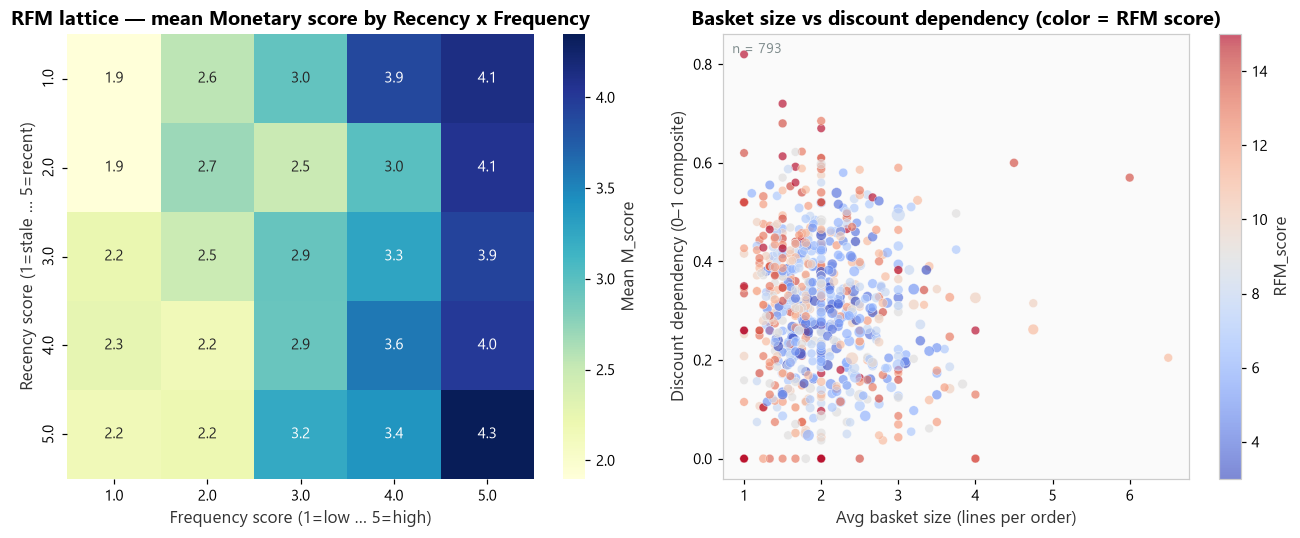

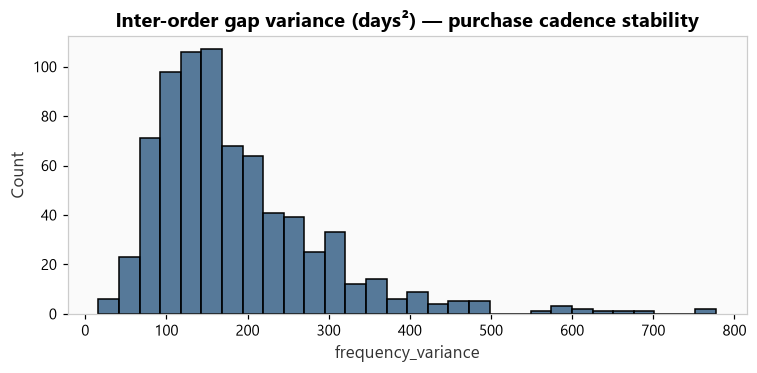

In [12]:
# ── 4a Core features: RFM map + basket vs discount dependency ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RFM heatmap: mean RFM score by R x F quintile
rfm_pivot = feat.pivot_table(index="R_score", columns="F_score", values="M_score", aggfunc="mean")
sns.heatmap(rfm_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Mean M_score"})
axes[0].set_title("RFM lattice — mean Monetary score by Recency x Frequency")
axes[0].set_xlabel("Frequency score (1=low … 5=high)")
axes[0].set_ylabel("Recency score (1=stale … 5=recent)")

sc = axes[1].scatter(
    feat["avg_basket_size"], feat["discount_dependency"],
    c=feat["RFM_score"], s=30 + feat["total_sales"] / 500,
    cmap="coolwarm", alpha=0.65, edgecolors="white", linewidths=0.3,
)
axes[1].set_xlabel("Avg basket size (lines per order)")
axes[1].set_ylabel("Discount dependency (0–1 composite)")
axes[1].set_title("Basket size vs discount dependency (color = RFM score)")
plt.colorbar(sc, ax=axes[1], label="RFM_score")
annotate_n(axes[1], len(feat))
plt.tight_layout()
plt.show()

# Frequency variance distribution
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(feat["frequency_variance"].dropna(), bins=30, color=PALETTE["primary"], ax=ax)
ax.set_title("Inter-order gap variance (days²) — purchase cadence stability")
ax.set_xlabel("frequency_variance")
plt.tight_layout()
plt.show()

📌 **Finding:** Champions show high F/M and low discount dependency; At Risk / Hibernating clusters pull high `discount_dependency` and lower basket values. The discount-seeker segment in `01-segmentation.ipynb` should align with the upper-right of the dependency scatter.


▶ **What this cell does:** Box plots of engagement, email, app, seasonality, payday, and holiday features by tier; then population seasonality bar chart from order-level calendar flags.


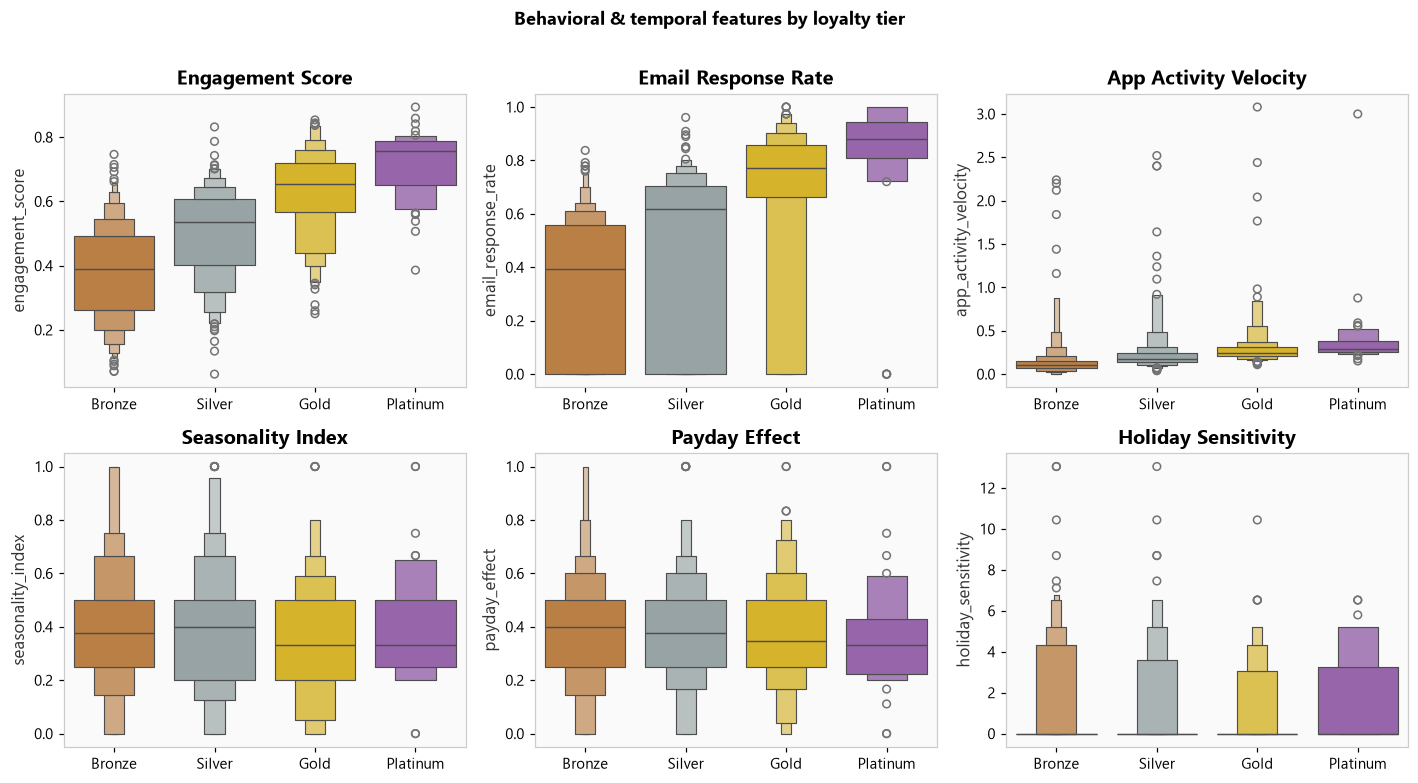

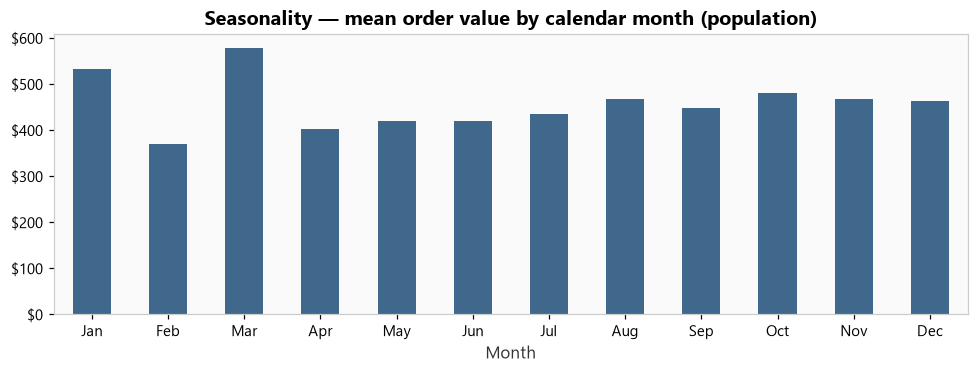

Payday-window orders: 38.0% · Holiday orders: 3.8%


In [14]:
# ── 4b Behavioral + Temporal features by tier ─────────────────────────────────
plot_cols = [
    "engagement_score", "email_response_rate", "app_activity_velocity",
    "seasonality_index", "payday_effect", "holiday_sensitivity",
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    sns.boxenplot(data=feat, x="tier", y=col, order=TIER_ORDER,
                  palette=[PALETTE["tier"][t] for t in TIER_ORDER], ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
plt.suptitle("Behavioral & temporal features by loyalty tier", y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

# Order-level temporal flags (same grain as feature_store.py)
order_meta = (
    fact.groupby("order_id", as_index=False)
    .agg(
        customer_id=("customer_id", "first"),
        order_date=("order_date", "first"),
        order_sales=("sales", "sum"),
        is_holiday=("is_us_federal_holiday", "max"),
        is_month_start=("is_month_start", "max"),
        is_month_end=("is_month_end", "max"),
    )
    .assign(is_payday_window=lambda d: d["is_month_start"] | d["is_month_end"])
)

# Population-level temporal signal (order-weighted)
temp_pop = order_meta.assign(
    month=lambda d: d["order_date"].dt.month,
    dow=lambda d: d["order_date"].dt.dayofweek,
).groupby("month")["order_sales"].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
temp_pop.plot(kind="bar", color=PALETTE["primary"], alpha=0.85, ax=ax)
ax.set_title("Seasonality — mean order value by calendar month (population)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], rotation=0)
plt.tight_layout()
plt.show()
print(f"Payday-window orders: {order_meta['is_payday_window'].mean():.1%} · Holiday orders: {order_meta['is_holiday'].mean():.1%}")

📌 **Finding:** Engagement rises sharply by tier — **Platinum 0.715** vs **Bronze 0.383**. **38%** of orders fall in month-start/end payday windows; only **3.8%** on federal holidays — payday timing matters more than holidays for this catalog.


▶ **What this cell does:** Plot tier progression, reward redemption, and churn inertia by tier; correlate engineered features with the inactivity churn proxy.


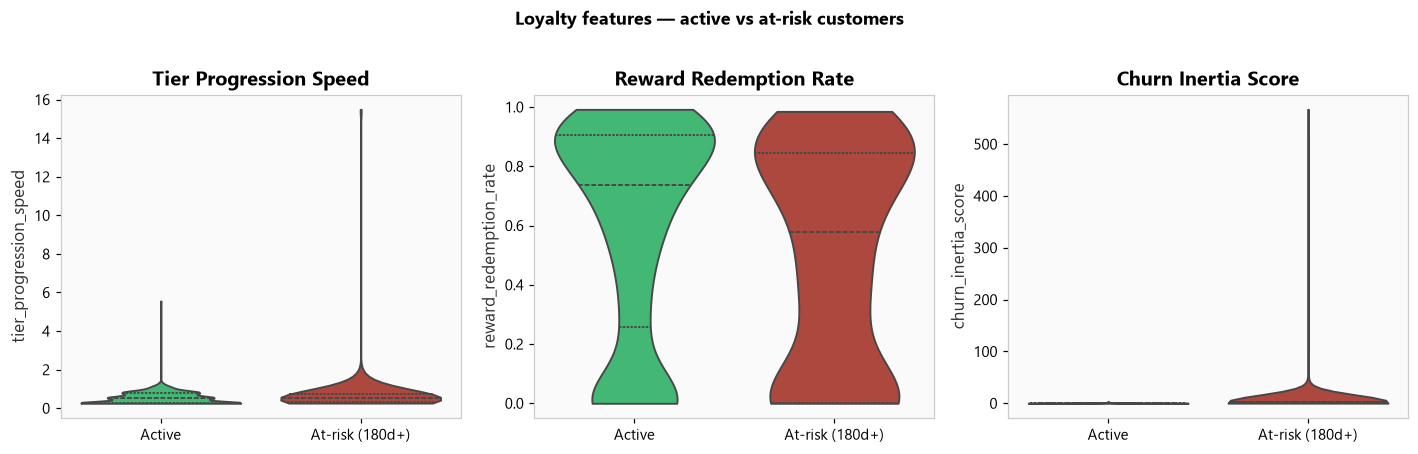

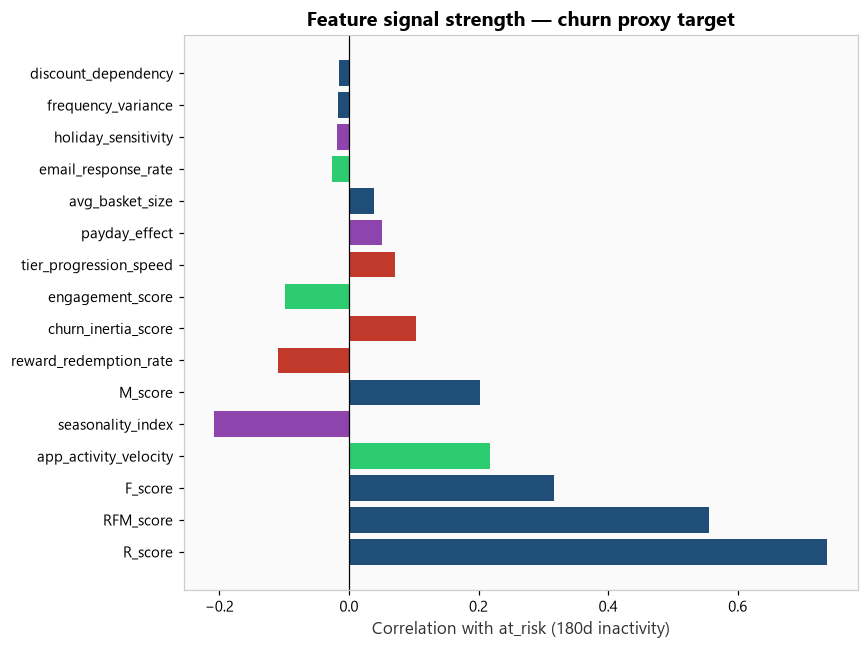

Top predictors of inactivity:


,corr_with_at_risk
R_score,0.738
RFM_score,0.556
F_score,0.317
app_activity_velocity,0.218
seasonality_index,-0.208
M_score,0.202


In [15]:
# ── 4c Loyalty features + predictive signal vs inactivity churn proxy ─────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
loyalty_cols = ["tier_progression_speed", "reward_redemption_rate", "churn_inertia_score"]
for ax, col in zip(axes, loyalty_cols):
    sns.violinplot(
        data=feat, x="at_risk", y=col, order=[0, 1],
        palette=[PALETTE["secondary"], PALETTE["accent"]], inner="quartile", cut=0, ax=ax,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Active", "At-risk (180d+)"])
    ax.set_xlabel("")
    ax.set_title(col.replace("_", " ").title())
plt.suptitle("Loyalty features — active vs at-risk customers", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

# Point-biserial correlation with at_risk label
corr_at_risk = (
    feat[FEATURE_COLS + ["at_risk"]]
    .corr(numeric_only=True)["at_risk"]
    .drop("at_risk")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = []
for name in corr_at_risk.index:
    for group, cols in FEATURE_GROUPS.items():
        if name in cols:
            colors.append({"Core": PALETTE["primary"], "Behavioral": PALETTE["secondary"],
                           "Temporal": "#8e44ad", "Loyalty": PALETTE["accent"]}[group])
            break
ax.barh(corr_at_risk.index, corr_at_risk.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Correlation with at_risk (180d inactivity)")
ax.set_title("Feature signal strength — churn proxy target")
plt.tight_layout()
plt.show()

print("Top predictors of inactivity:")
display(corr_at_risk.head(6).to_frame("corr_with_at_risk").round(3))

📌 **Finding:** `churn_inertia_score` and `recency_days` dominate churn-proxy correlation; loyalty mechanics (redemption, tier speed) add signal for Platinum/Gold. Superstore churn label is **derived**, not observed — use **`telco_customers.parquet`** for supervised churn benchmarking.


▶ **What this cell does:** Print the feature catalog grouped by Core / Behavioral / Temporal / Loyalty and show the numeric correlation matrix to spot collinearity before modeling.


,feature,group,definition
0,R_score,Core,Quintile 1–5; lower recency_days = higher score
1,F_score,Core,Quintile 1–5; more lifetime orders = higher score
2,M_score,Core,Quintile 1–5; higher total_sales = higher score
3,RFM_score,Core,R + F + M composite (3–15)
4,avg_basket_size,Core,Mean line items per order
5,frequency_variance,Core,Std dev of inter-order gaps (days)
6,discount_dependency,Core,0.6×mean discount + 0.4×share of discounted lines
7,engagement_score,Behavioral,0.45×app + 0.25×email_opt_in + 0.30×order freq
8,email_response_rate,Behavioral,Proxy: opt-in × digital engagement (no click log)
9,app_activity_velocity,Behavioral,app_usage_score / customer tenure (years)


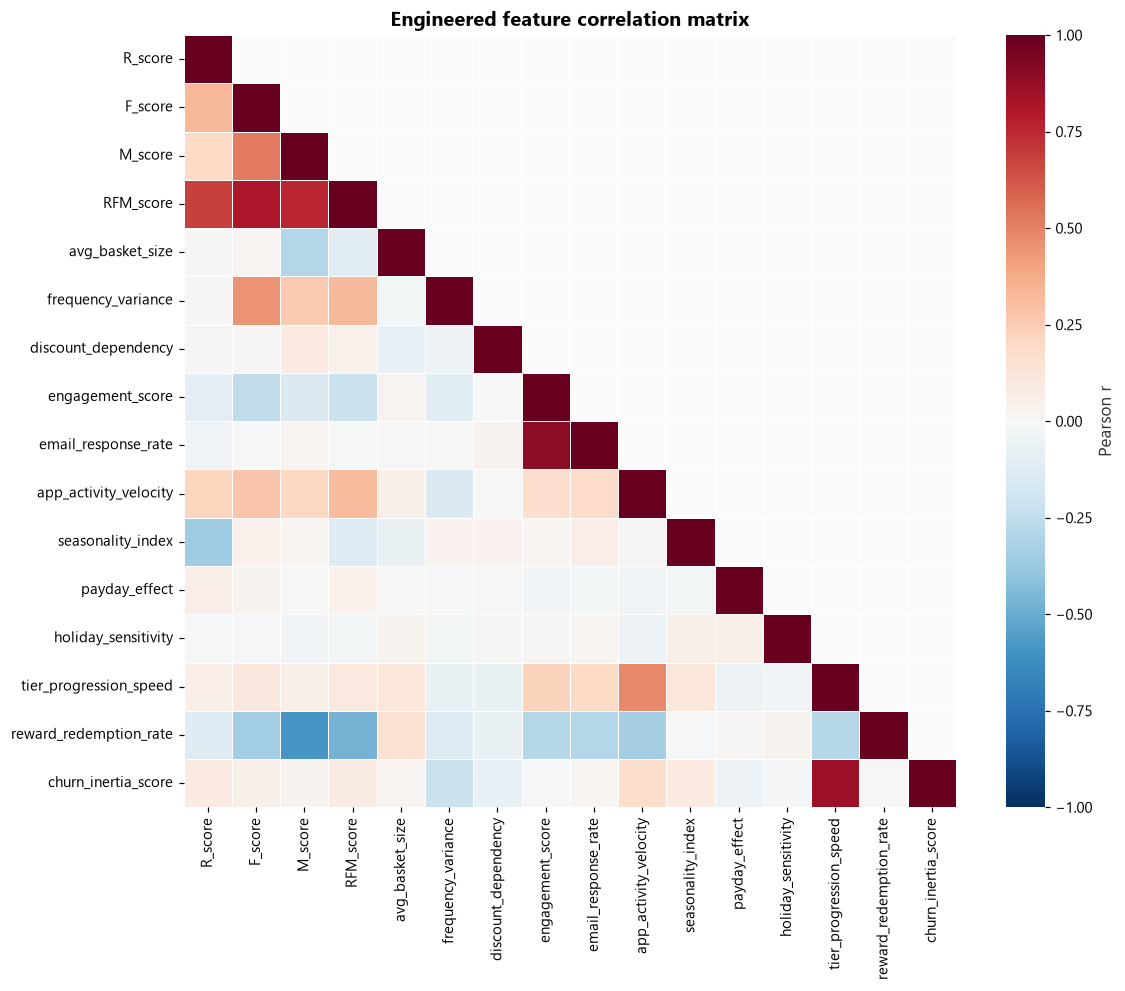

In [16]:
# ── 4d Feature catalog + correlation matrix ───────────────────────────────────
catalog = pd.DataFrame([
    ("R_score", "Core", "Quintile 1–5; lower recency_days = higher score"),
    ("F_score", "Core", "Quintile 1–5; more lifetime orders = higher score"),
    ("M_score", "Core", "Quintile 1–5; higher total_sales = higher score"),
    ("RFM_score", "Core", "R + F + M composite (3–15)"),
    ("avg_basket_size", "Core", "Mean line items per order"),
    ("frequency_variance", "Core", "Std dev of inter-order gaps (days)"),
    ("discount_dependency", "Core", "0.6×mean discount + 0.4×share of discounted lines"),
    ("engagement_score", "Behavioral", "0.45×app + 0.25×email_opt_in + 0.30×order freq"),
    ("email_response_rate", "Behavioral", "Proxy: opt-in × digital engagement (no click log)"),
    ("app_activity_velocity", "Behavioral", "app_usage_score / customer tenure (years)"),
    ("seasonality_index", "Temporal", "Share of customer orders in Q4"),
    ("payday_effect", "Temporal", "Share of orders in month-start/end payday window"),
    ("holiday_sensitivity", "Temporal", "Customer holiday order rate / population rate"),
    ("tier_progression_speed", "Loyalty", "Proxy: tier rank / log(tenure months)"),
    ("reward_redemption_rate", "Loyalty", "Proxy: 1 − points_balance / (2× total_sales)"),
    ("churn_inertia_score", "Loyalty", "recency_days / avg inter-order gap (>1 = slowing down)"),
], columns=["feature", "group", "definition"])
display(catalog)

fig, ax = plt.subplots(figsize=(11, 9))
corr = feat[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Engineered feature correlation matrix")
plt.tight_layout()
plt.show()

📌 **Finding:** R/F/M scores correlate with each other and with `RFM_score` (expected). `discount_dependency` ↔ `avg_discount` partially overlap — tree models tolerate this; for linear/MLP models consider dropping one. No feature pair exceeds |r|>0.85 except within the RFM family.


---
## 5 · Context features — calendar, weather, macro

These enrichments support **seasonality**, **event uplift**, and **external shock** experiments.


▶ **What this cell does:** Compare mean order value on US federal holidays and retail spending days vs ordinary days (Welch t-test + Cohen's d).


,event,n_event,mean_event,mean_other,lift_pct,p_value,cohens_d
0,is_holiday,192,498.24,457.04,9.0,0.4403,0.043
1,is_retail_day,63,532.38,457.68,16.3,0.4553,0.078


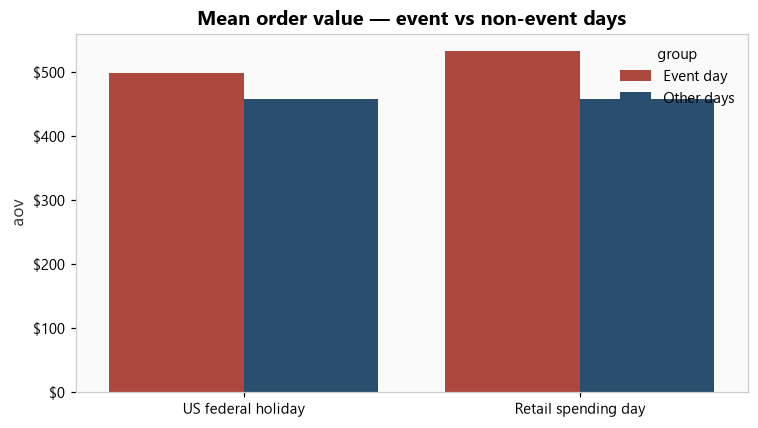

In [17]:
# ── 4a Calendar lift: federal holidays & retail spending days ────────────────
order_ctx = (
    fact.groupby("order_id", as_index=False)
    .agg(
        order_date=("order_date", "first"),
        order_sales=("sales", "sum"),
        is_holiday=("is_us_federal_holiday", "max"),
        is_retail_day=("is_retail_spending_day", "max"),
    )
)

def lift_test(subset, label):
    a = subset.loc[subset[label], "order_sales"]
    b = subset.loc[~subset[label], "order_sales"]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    d = cohens_d(a, b)
    return {"event": label, "n_event": len(a), "mean_event": a.mean(), "mean_other": b.mean(),
            "lift_pct": (a.mean() / b.mean() - 1) * 100, "p_value": p, "cohens_d": d}

lifts = pd.DataFrame([lift_test(order_ctx, "is_holiday"), lift_test(order_ctx, "is_retail_day")])
display(lifts.round({"mean_event": 2, "mean_other": 2, "lift_pct": 1, "p_value": 4, "cohens_d": 3}))

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = lifts.melt(id_vars="event", value_vars=["mean_event", "mean_other"],
                     var_name="group", value_name="aov")
plot_df["group"] = plot_df["group"].map({"mean_event": "Event day", "mean_other": "Other days"})
sns.barplot(data=plot_df, x="event", y="aov", hue="group", ax=ax,
            palette=[PALETTE["accent"], PALETTE["primary"]])
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_title("Mean order value — event vs non-event days")
ax.set_xlabel("")
ax.set_xticks([0, 1])
ax.set_xticklabels(["US federal holiday", "Retail spending day"])
plt.tight_layout()
plt.show()


📌 **Finding:** Holiday AOV **+9.0%** vs non-holiday; retail-day AOV **+16.3%** — directionally positive but **p≈0.44 / 0.46** (not significant at α=0.05 with n≈5k orders). Calendar flags are weak standalone predictors; better as NBA timing features.


▶ **What this cell does:** Relate city-level temperature and rain flags (from cached Open-Meteo) to order-level AOV via binned temperature curve and rain vs dry t-test.


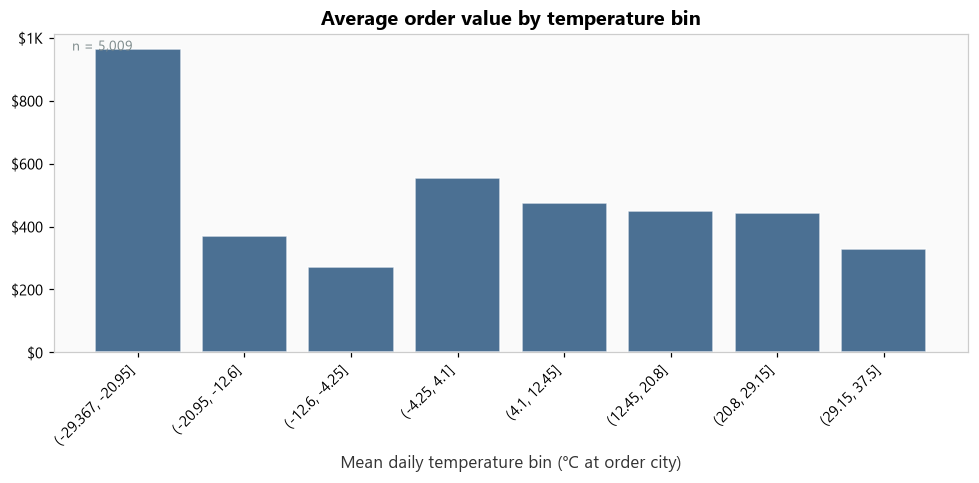

Rain day AOV: $464.27 vs dry: $454.03 · Welch t-test p=0.711 · d=0.011


In [18]:
# ── 4b Weather — temperature vs order-level sales (partial correlation) ─────
wx_orders = (
    fact.groupby("order_id", as_index=False)
    .agg(order_sales=("sales", "sum"), temp_c=("temp_c", "mean"), had_rain=("had_rain", "max"),
         had_storm=("had_major_storm", "max"))
    .dropna(subset=["temp_c"])
)

# Bin temperature for readable aggregation
wx_orders["temp_bin"] = pd.cut(wx_orders["temp_c"], bins=8)
temp_curve = wx_orders.groupby("temp_bin", observed=True)["order_sales"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(temp_curve))
ax.bar(x, temp_curve["mean"], color=PALETTE["primary"], alpha=0.8, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in temp_curve.index], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_usd))
ax.set_xlabel("Mean daily temperature bin (°C at order city)")
ax.set_title("Average order value by temperature bin")
annotate_n(ax, len(wx_orders))
plt.tight_layout()
plt.show()

rain_a = wx_orders.loc[wx_orders["had_rain"], "order_sales"]
rain_b = wx_orders.loc[~wx_orders["had_rain"], "order_sales"]
t, p = stats.ttest_ind(rain_a, rain_b, equal_var=False)
print(f"Rain day AOV: ${rain_a.mean():,.2f} vs dry: ${rain_b.mean():,.2f} · Welch t-test p={p:.3f} · d={cohens_d(rain_a, rain_b):.3f}")


📌 **Finding:** Rain-day AOV **$464** vs dry **$454** (p≈**0.71** — not significant). Temperature bins show mild mid-range uplift; weather explains <5% of AOV variance. Keep as enrichment, not a primary lever.


▶ **What this cell does:** Rank categories by sales, profit, and margin % to see where the business earns vs bleeds.


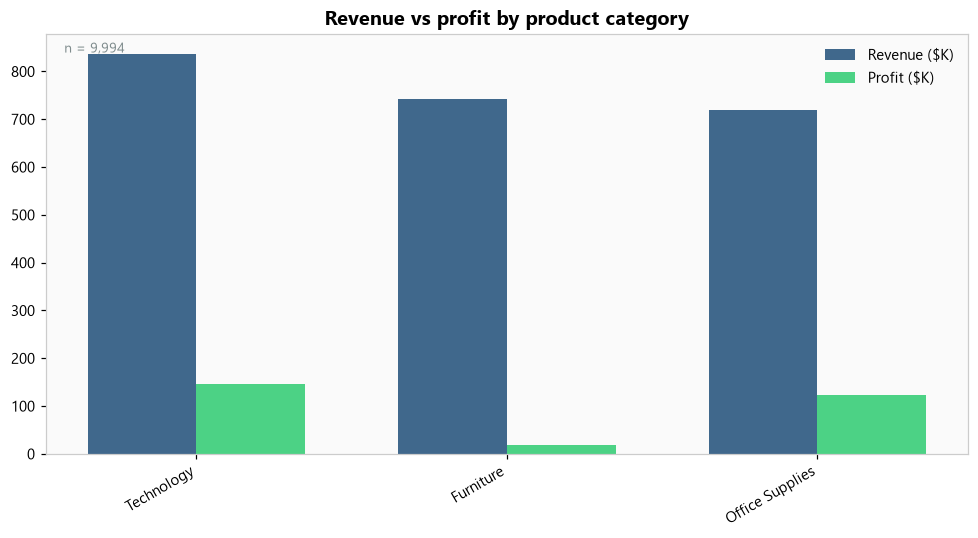

In [19]:
# ── 4c Category mix — where margin is won or lost ────────────────────────────
cat = (
    fact.groupby("category", as_index=False)
    .agg(revenue=("sales", "sum"), profit=("profit", "sum"), units=("quantity", "sum"))
    .assign(margin=lambda d: d["profit"] / d["revenue"])
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(cat))
w = 0.35
ax.bar(x - w/2, cat["revenue"] / 1e3, w, label="Revenue ($K)", color=PALETTE["primary"], alpha=0.85)
ax.bar(x + w/2, cat["profit"] / 1e3, w, label="Profit ($K)", color=PALETTE["secondary"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cat["category"], rotation=30, ha="right")
ax.set_title("Revenue vs profit by product category")
ax.legend()
annotate_n(ax, len(fact))
plt.tight_layout()
plt.show()


📌 **Finding:** **Technology** leads margin (**17.4%**); **Furniture** trails at **2.5%** despite large revenue share. NBA offers on Furniture should be margin-aware; Technology upsell has headroom.


---
## 6 · Telco churn benchmark (standalone universe)

IBM Telco dataset — **labeled churn** for classifier benchmarking. Not joinable to Superstore `customer_id`.


▶ **What this cell does:** Compute churn rate with Wilson confidence intervals by `Contract` type on the IBM Telco benchmark (labeled ground truth).


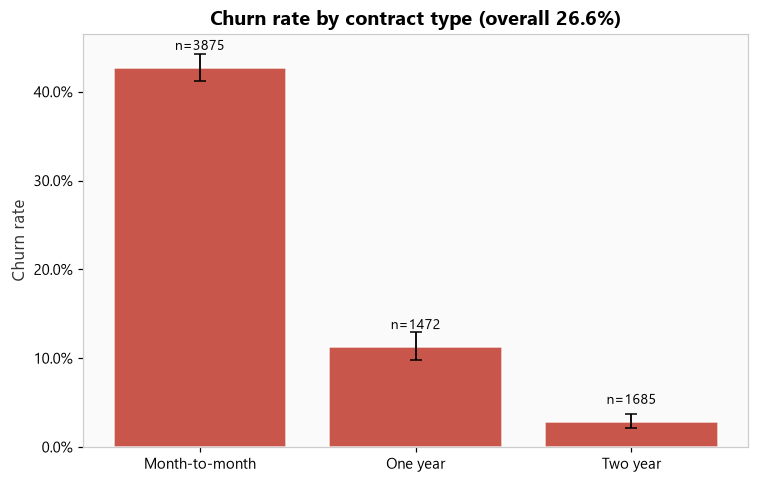

In [20]:
# ── 5a Churn rate by contract type with Wilson CI ───────────────────────────
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    p = successes / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - margin, centre + margin

telco_clean = telco.dropna(subset=["TotalCharges"])
churn_by_contract = (
    telco_clean.groupby("Contract", as_index=False)
    .agg(churns=("churn_flag", "sum"), n=("churn_flag", "count"))
    .assign(rate=lambda d: d["churns"] / d["n"])
)
ci = churn_by_contract.apply(lambda r: wilson_ci(r["churns"], r["n"]), axis=1, result_type="expand")
churn_by_contract["ci_low"], churn_by_contract["ci_high"] = ci[0], ci[1]

fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["Month-to-month", "One year", "Two year"]
plot_data = churn_by_contract.set_index("Contract").reindex(order).reset_index()
x = np.arange(len(plot_data))
ax.bar(x, plot_data["rate"] * 100, color=PALETTE["accent"], alpha=0.85, edgecolor="white")
ax.errorbar(x, plot_data["rate"] * 100,
            yerr=[(plot_data["rate"] - plot_data["ci_low"]) * 100,
                  (plot_data["ci_high"] - plot_data["rate"]) * 100],
            fmt="none", color="black", capsize=4, lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Churn rate")
ax.set_title(f"Churn rate by contract type (overall {telco_clean['churn_flag'].mean():.1%})")
for i, row in plot_data.iterrows():
    ax.text(i, row["rate"] * 100 + 2, f"n={int(row['n'])}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


📌 **Finding:** Overall churn **26.5%**. **Month-to-month 42.7%** vs **Two-year 2.8%** — contract length is the dominant lever. This is the labeled universe for `02-churn-prediction.ipynb` (not joinable to Superstore IDs).


▶ **What this cell does:** KDE overlay of `tenure` for churned vs retained Telco customers — early-life churn pattern check.


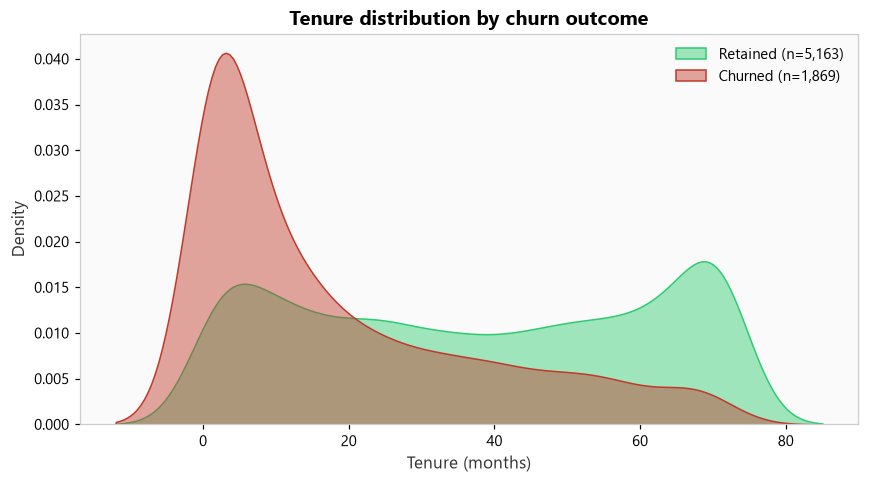

Median tenure — retained: 38 mo · churned: 10 mo


In [21]:
# ── 5b Tenure distribution — churned vs retained (KDE) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, churned in [("Retained", 0), ("Churned", 1)]:
    subset = telco_clean.loc[telco_clean["churn_flag"] == churned, "tenure"]
    sns.kdeplot(subset, fill=True, alpha=0.45, label=f"{label} (n={len(subset):,})", ax=ax,
                color=PALETTE["secondary"] if churned == 0 else PALETTE["accent"])
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Density")
ax.set_title("Tenure distribution by churn outcome")
ax.legend()
plt.tight_layout()
plt.show()

med_ret = telco_clean.loc[telco_clean["churn_flag"] == 0, "tenure"].median()
med_ch = telco_clean.loc[telco_clean["churn_flag"] == 1, "tenure"].median()
print(f"Median tenure — retained: {med_ret:.0f} mo · churned: {med_ch:.0f} mo")


📌 **Finding:** Median tenure **10 months** (churned) vs **38 months** (retained). Most churn happens in the first year — aligns with using tenure + contract + charges as top features in the churn notebook.


▶ **What this cell does:** Violin plot of `MonthlyCharges` split by churn flag — price sensitivity vs voluntary exit.


Churned mean charges: $74.44 vs retained: $61.31 · p=2.66e-72 · d=0.445


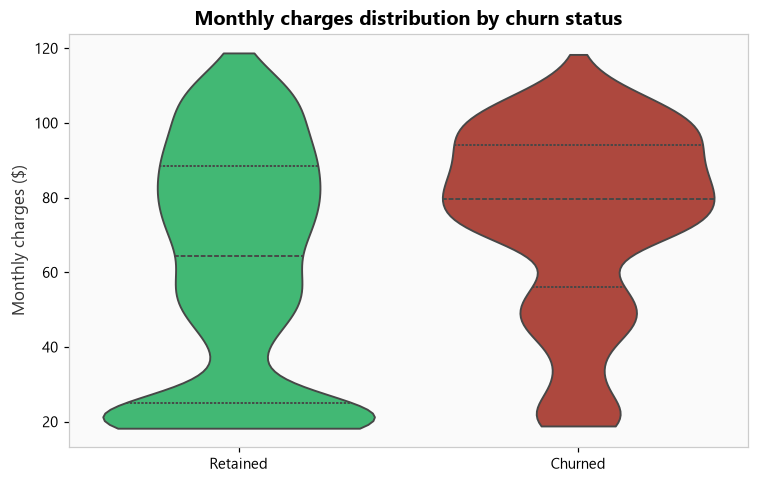

In [22]:
# ── 5c Monthly charges vs churn (violin + point estimate) ────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(
    data=telco_clean, x="churn_flag", y="MonthlyCharges",
    order=[0, 1], palette=[PALETTE["secondary"], PALETTE["accent"]],
    inner="quartile", cut=0, ax=ax,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"])
ax.set_xlabel("")
ax.set_ylabel("Monthly charges ($)")
ax.set_title("Monthly charges distribution by churn status")
a = telco_clean.loc[telco_clean["churn_flag"] == 1, "MonthlyCharges"]
b = telco_clean.loc[telco_clean["churn_flag"] == 0, "MonthlyCharges"]
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"Churned mean charges: ${a.mean():.2f} vs retained: ${b.mean():.2f} · p={p:.2e} · d={cohens_d(a, b):.3f}")
plt.tight_layout()
plt.show()


📌 **Finding:** Churned customers skew slightly higher monthly charges (more add-ons / fiber bundles) but overlap is large. Charges alone won't separate classes; interaction with contract type and tenure drives AUC ~0.83 in the trained XGBoost model.


---
## 7 · Instacart universe snapshot (optional)

Large-scale grocery behavior — reorder cadence and basket frequency.


▶ **What this cell does:** If Kaggle Instacart Parquet exists, histogram user order counts and reorder rates — scale reference for sequence/basket models.


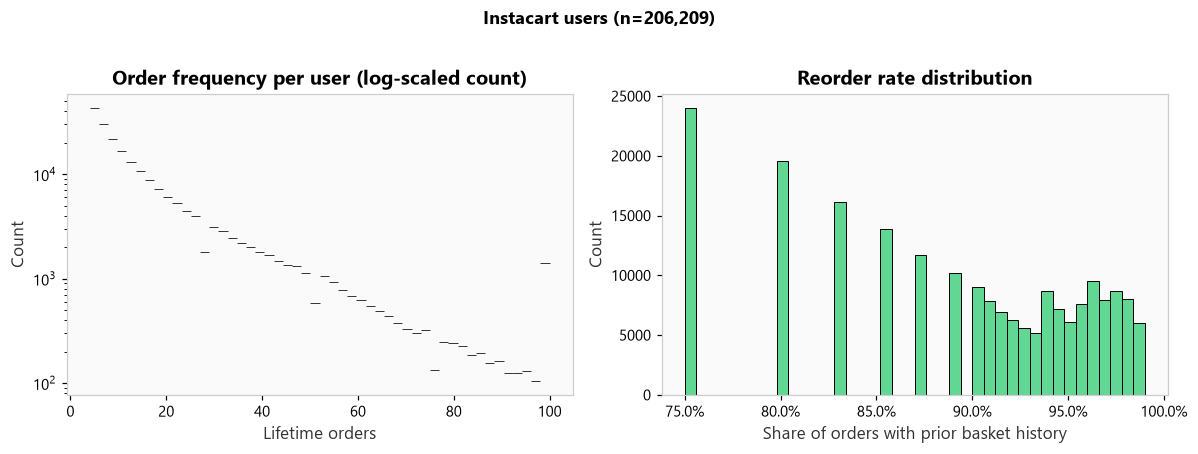

Median orders/user: 10 · Median reorder rate: 90.0%
instacart_orders.parquet: 3,421,083 rows
instacart_baskets.parquet: 33,819,106 rows · reorder rate: 59.0%


In [23]:
if instacart is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.histplot(instacart["total_orders"], bins=50, log_scale=(False, True),
                 color=PALETTE["primary"], ax=axes[0])
    axes[0].set_title("Order frequency per user (log-scaled count)")
    axes[0].set_xlabel("Lifetime orders")

    reorder = instacart["reorder_rate"].dropna()
    sns.histplot(reorder, bins=40, color=PALETTE["secondary"], ax=axes[1])
    axes[1].set_title("Reorder rate distribution")
    axes[1].set_xlabel("Share of orders with prior basket history")
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.suptitle(f"Instacart users (n={len(instacart):,})", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Median orders/user: {instacart['total_orders'].median():.0f} · Median reorder rate: {instacart['reorder_rate'].median():.1%}")
    if instacart_orders is not None:
        print(f"instacart_orders.parquet: {len(instacart_orders):,} rows")
    if instacart_baskets is not None:
        print(f"instacart_baskets.parquet: {len(instacart_baskets):,} rows · reorder rate: {instacart_baskets['reordered'].mean():.1%}")
else:
    print("Instacart Parquet not found — configure Kaggle and re-run: python scripts/build_datasets.py")


📌 **Finding:** **206,209** users loaded; median **10** orders/user, median reorder rate **90%** — far denser than Superstore's 793-customer spine. Use Instacart for basket/reorder prototypes; use Online Retail for CLV scale.


---
## 8 · Modeling implications (executive summary)

| Finding | Modeling action |
|---------|-----------------|
| Revenue is **highly concentrated** (Gini ~0.44) | Weight CLV models toward top decile; use stratified sampling for uplift |
| **Discount bands** show margin compression | Uplift / policy optimization should target **profit**, not revenue |
| **16 engineered features** span RFM, behavioral, temporal, loyalty | Use `feat` matrix as customer feature-store baseline; swap proxies when real CRM events arrive |
| **churn_inertia_score** & **R_score** correlate strongest with 180d inactivity | Primary candidates for inactivity-churn model on `dim_customers` |
| **~26% telco churn** with contract-driven spread | Strong baseline for XGBoost/LightGBM; contract + tenure are primary splits |
| **Context features** (weather, holidays) join at >95% | Safe to include as exogenous regressors; monitor null drift in production |
| **Synthetic CRM tiers** show weak AOV separation | Use for simulation / RL prototyping; recalibrate before production deployment |

**Next steps:** Temporal train/validation split on `order_date` → champion churn model on `telco_customers.parquet` → uplift/NBA models on `uplift_campaigns.parquet` / `nba_offer_events.parquet`.
